In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [17]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [18]:
df = pd.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
794,2014,MINI,COOPER S CONVERTIBLE,MINICOMPACT,1.6,4,A6,Z,9.3,7.0,8.3,34,191
816,2014,MITSUBISHI,LANCER,COMPACT,2.0,4,AV6,X,9.2,7.0,8.2,34,189
541,2014,INFINITI,QX60,SUV - SMALL,3.5,6,AV,Z,11.9,9.0,10.6,27,244
207,2014,CHEVROLET,EQUINOX AWD,SUV - SMALL,2.4,4,A6,X,11.5,8.2,10.0,28,230
565,2014,JAGUAR,XKR CONVERTIBLE,MINICOMPACT,5.0,8,AS6,Z,15.9,10.9,13.7,21,315


In [19]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [20]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1062,3.0,6,11.8,271
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


In [21]:
df.sample(5)
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]

In [22]:
viz

,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,4,2.0,8.5,196
1,4,2.4,9.6,221
2,4,1.5,5.9,136
3,6,3.5,11.1,255
4,6,3.5,10.6,244
...,...,...,...,...
1062,6,3.0,11.8,271
1063,6,3.2,11.5,264
1064,6,3.0,11.8,271
1065,6,3.2,11.3,260


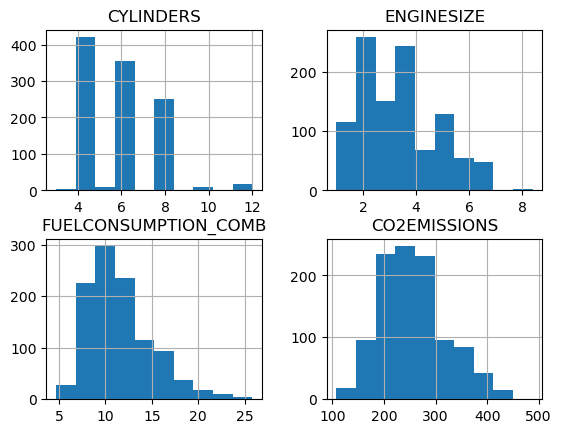

In [23]:
viz.hist()
plt.show()

In [24]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

**Create train and test datasets**


In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.4,random_state = 42)

In [34]:
regressor = LinearRegression()


In [35]:
regressor.fit(X_train.reshape(-1,1),y_train)

LinearRegression()

In [36]:
print('Coefficient:',regressor.coef_)


Coefficient: [38.65069602]


In [38]:
print('Intercept:',regressor.intercept_)

Intercept: 127.56269270357325


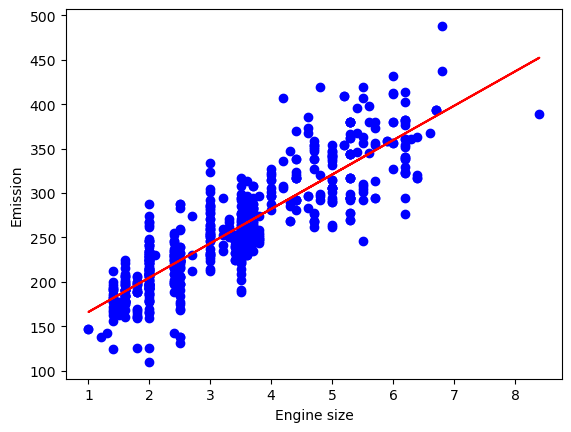

In [39]:
plt.scatter(X_train,y_train,color = 'blue')
plt.plot(X_train,regressor.coef_ * X_train + regressor.intercept_,'-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()